## 1. Project Overview


CO3057 Computer Vision and Digital Image Preprocessing Project

## 2. Library Imports


In [1]:
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import cv2.aruco as aruco
import json
import glob

## 3. Global Constants and Configuration

In [2]:
DIRPATH = "./flyingarucov2"

ARUCO_DICT = aruco.getPredefinedDictionary(aruco.DICT_ARUCO_MIP_36h12)
ARUCO_PARAMS = aruco.DetectorParameters()

## 4. Utility Functions

In [3]:
def load_data(img_id):
    img_path = os.path.join(DIRPATH, f"{img_id}.jpg")
    json_path = os.path.join(DIRPATH, f"{img_id}.json")

    img = cv2.imread(img_path)
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    return img, data

In [4]:
def convert_to_yolo_file():
    label_dir = os.path.join(DIRPATH, 'labels')
    if os.path.exists(label_dir) and len(os.listdir(label_dir)) > 0:
        print(f'{label_dir} already exists.')
        return
        
    os.makedirs(label_dir, exist_ok=True)

    json_files = glob.glob(os.path.join(DIRPATH, '*.json'))

    for json_file in json_files:
        # 1. Lấy file ảnh
        file_id = os.path.basename(json_file).replace('.json', '')
        img_path = os.path.join(DIRPATH, f'{file_id}.jpg')

        # 2. Lấy shape để normalize
        img = cv2.imread(img_path)
        height, width, _ = img.shape

        # 3. Đọc file json
        with open(json_file, 'r') as f:
            data = json.load(f)

        lines = []
        for marker in data['markers']:
            corner = marker['corners']

            # Normalize data
            xs = [c[0] for c in corner]
            ys = [c[1] for c in corner]
                
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)

            x_mid_norm = ((x_min + x_max) / 2) / width
            y_mid_norm = ((y_min + y_max) / 2) / height

            w_norm = (x_max - x_min) / width
            h_norm = (y_max - y_min) / height

            line = f'0 {x_mid_norm:.6f} {y_mid_norm:.6f} {w_norm:.6f} {h_norm:.6f}'
            lines.append(line)

        # 4. Ghi file
        txt_file = os.path.join(label_dir, f'{file_id}.txt')
        with open(txt_file, 'w') as f:
            f.write('\n'.join(lines))

convert_to_yolo_file()

./flyingarucov2\labels already exists.


In [5]:
import shutil
import random

def split_dataset(src_dir, train_ratio=.8):
    base_dir = "dataset"
    sub_dirs = ["images/train", "images/val", "labels/train", "labels/val"]

    for sub in sub_dirs:
        try:
            os.makedirs(os.path.join(base_dir, sub))
        except FileExistsError:
            print(f"Folder images and labels already exist")
            return
        
    all_ids = [f.replace('.jpg', '') for f in os.listdir(src_dir) if f.endswith('.jpg')]
    random.seed(42)
    random.shuffle(all_ids)

    split_index = int(len(all_ids) * train_ratio)
    train_ids = all_ids[:split_index]
    val_ids = all_ids[split_index:]

    def move_files(ids, split_name):
        label_src_dir = os.path.join(src_dir, "labels")
        for id in ids:
            # Di chuyển ảnh
            img_src = os.path.join(src_dir, f"{id}.jpg")
            img_dst = os.path.join(base_dir, f"images/{split_name}/{id}.jpg")
            if os.path.exists(img_src):
                shutil.copy(img_src, img_dst)

            txt_src = os.path.join(label_src_dir, f"{id}.txt")
            txt_dst = os.path.join(base_dir, f"labels/{split_name}/{id}.txt")
            if os.path.exists(txt_src):
                shutil.copy(txt_src, txt_dst)

    move_files(train_ids, "train")
    move_files(val_ids, "val")

split_dataset(DIRPATH)


Folder images and labels already exist


## 5. Core

## Aruco marker detection
Use yolo to train

In [6]:
from ultralytics import YOLO

model_train = YOLO("yolov8n.pt")

In [7]:
name = "aruco_v3"

# results = model_train.train(
#     data="data.yaml",
#     epochs=50,
#     imgsz=640,
#     batch=16,
#     device=0,
#     project="aruco_btl",
#     name=name,
#     workers=0,
#     exist_ok=True
# )

## Load model
If you do not have model already, please train it!

In [8]:
model_path = f"runs/detect/aruco_btl/{name}/weights/best.pt"
model = YOLO(model_path)

detector = aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMS)

### 1. Object detection

In [9]:
def get_yolo_regions(image, model, confident_threshold=.5):
    results = model.predict(image, conf=confident_threshold, verbose=False)

    boxes = results[0].boxes.xyxy.cpu().numpy()
    return boxes

### 2. ROI Extraction and Padding

In [10]:
def extract_roi(image, box, padding=20):
    height, width, _ = image.shape

    x1, y1, x2, y2 = map(int, box)

    x1_p = max(0, x1 - padding)
    y1_p = max(0, y1 - padding)
    x2_p = min(width, x2 + padding)
    y2_p = min(height, y2 + padding)

    roi = image[y1_p:y2_p, x1_p:x2_p]
    return roi, (x1_p, y1_p)                # The pos of coordinate is offset used in decoding

### 3. Decoding

In [11]:
def decode_aruco(roi, offset):
    corners, ids, _ = detector.detectMarkers(roi)

    real_corners = []
    if ids is not None:
        for c in corners:
            real_corners.append(c + offset)
    
    return real_corners, ids

### 4. Full pipeline

In [15]:
def full_pipeline(image_path, model):
    img = cv2.imread(image_path)
    output = []

    boxes = get_yolo_regions(img, model)

    for box in boxes:
        roi, offset = extract_roi(img, box, 10)
        corners, ids = decode_aruco(roi, offset)

        if ids is not None:
            id_list = ids[0][0]
            for i in range(len(ids)):
                top_left = corners[i][0][0]
                pred = f"{id_list} {top_left[0]} {top_left[1]}"
                output.append(pred)

    return " ".join(output)

### 5. Run

360 640


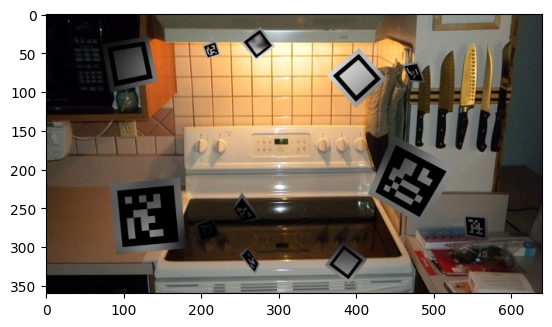

In [16]:
img_temp = cv2.imread("flyingarucov2/000000000089.jpg")
img_temp = cv2.cvtColor(img_temp, cv2.COLOR_BGR2RGB)
plt.imshow(img_temp)
h, w, _ = img_temp.shape
print(h, w, sep= " ")

In [19]:
res = full_pipeline("flyingarucov2/000000000089.jpg", model)
print(res)

29 482.0 261.0 78 170.0 294.0 188 485.0 86.0 117 543.0 283.0 202 196.0 273.0 184 218.0 38.0


## 6. Evaluation